In [14]:
"""
Arrival Time Front Propagation (ATFP) Clustering
================================================

Dijkstra-style arrival-time based front propagation clustering.

Features:
• 8 speed modulation variants
• 6 seed selection strategies
• True shortest-path arrival propagation

Author: Your Name
License: MIT
"""

import numpy as np
import heapq
from sklearn.neighbors import NearestNeighbors


class ArrivalTimeFrontPropagation:

    def __init__(self,
                 n_clusters,
                 k_neighbors=15,
                 speed_variant="density",
                 seed_strategy="speed_farthest",
                 random_state=42):

        self.n_clusters = n_clusters
        self.k_neighbors = k_neighbors
        self.speed_variant = speed_variant
        self.seed_strategy = seed_strategy
        self.random_state = random_state
        self.labels_ = None


    # ==========================================================
    # LOCAL STATISTICS
    # ==========================================================

    def _local_stats(self, X):
        k = min(self.k_neighbors, len(X))
        nbrs = NearestNeighbors(n_neighbors=k).fit(X)
        dists, idx = nbrs.kneighbors(X)

        d_avg = dists.mean(axis=1)
        rho = 1.0 / (d_avg + 1e-9)
        sigma = dists.std(axis=1)

        return rho, sigma, d_avg, idx


    # ==========================================================
    # SPEED VARIANTS
    # ==========================================================

    def _speed(self, rho, sigma, d_avg):
        EPS = 1e-9

        rho_safe = np.maximum(rho, EPS)
        sigma_safe = np.maximum(sigma, EPS)

        if self.speed_variant == "density":
            return rho_safe

        elif self.speed_variant == "rho_sigma":
            sigma_norm = sigma_safe / (sigma_safe.max() + EPS)
            return rho_safe * np.exp(-sigma_norm)

        elif self.speed_variant == "sigmoid_sigma":
            sigma_norm = sigma_safe / (sigma_safe.max() + EPS)
            return rho_safe * (1.0 / (1.0 + np.exp(0.5 * (sigma_norm - 0.5))))

        elif self.speed_variant == "no_normalization":
            sigma_clipped = np.minimum(sigma_safe, 50.0)
            return rho_safe * np.exp(-sigma_clipped)

        elif self.speed_variant == "quadratic_sigma":
            sigma_norm = sigma_safe / (sigma_safe.max() + EPS)
            return rho_safe * np.exp(-sigma_norm ** 2)

        elif self.speed_variant == "inverse_sigma":
            sigma_norm = sigma_safe / (sigma_safe.max() + EPS)
            return rho_safe / (sigma_norm + 1.0)

        elif self.speed_variant == "sqrt_sigma":
            sigma_norm = sigma_safe / (sigma_safe.max() + EPS)
            return rho_safe * np.exp(-np.sqrt(sigma_norm))

        elif self.speed_variant == "log_density":
            gamma = np.clip(d_avg, 0.1, 10.0)
            sigma_norm = sigma_safe / (sigma_safe.max() + EPS)
            return np.log1p(rho_safe) * np.exp(-gamma * sigma_norm)

        else:
            raise ValueError(f"Unknown speed variant: {self.speed_variant}")


    # ==========================================================
    # SEED DISPATCHER
    # ==========================================================

    def _select_seeds(self, X, rho, speeds):

        if self.seed_strategy == "random":
            return self._select_seeds_random(X)

        elif self.seed_strategy == "density_maximin":
            return self._select_seeds_density_maximin(X, rho)

        elif self.seed_strategy == "density_peaks":
            return self._select_seeds_density_peaks(X, rho)

        elif self.seed_strategy == "speed_farthest":
            return self._select_seeds_speed_farthest(X, speeds)

        elif self.seed_strategy == "kmeans_plusplus":
            return self._select_seeds_kmeans_plusplus(X, rho)

        elif self.seed_strategy == "crowded_farthest":
            return self._select_seeds_crowded_farthest(X)

        else:
            raise ValueError(f"Unknown seed strategy: {self.seed_strategy}")


    # ==========================================================
    # SEED STRATEGIES
    # ==========================================================

    def _select_seeds_random(self, X):
        rng = np.random.RandomState(self.random_state)
        return rng.choice(len(X), self.n_clusters, replace=False).tolist()


    def _select_seeds_density_maximin(self, X, rho):
        seeds = [np.argmax(rho)]

        for _ in range(self.n_clusters - 1):
            dists = np.min([np.linalg.norm(X - X[s], axis=1)
                            for s in seeds], axis=0)
            score = dists * rho
            seeds.append(np.argmax(score))

        return seeds


    def _select_seeds_density_peaks(self, X, rho):
        delta = np.zeros(len(X))

        for i in range(len(X)):
            higher = np.where(rho > rho[i])[0]
            if len(higher) > 0:
                delta[i] = np.min(np.linalg.norm(X[i] - X[higher], axis=1))
            else:
                delta[i] = np.max(np.linalg.norm(X[i] - X, axis=1))

        gamma = rho * delta
        return np.argsort(-gamma)[:self.n_clusters].tolist()


    def _select_seeds_speed_farthest(self, X, speeds):
        seeds = [np.argmax(speeds)]

        while len(seeds) < self.n_clusters:
            dists = np.min([np.linalg.norm(X - X[s], axis=1)
                            for s in seeds], axis=0)
            score = speeds * (dists ** 1.5)
            seeds.append(np.argmax(score))

        return seeds


    def _select_seeds_kmeans_plusplus(self, X, rho):
        rng = np.random.RandomState(self.random_state)
        seeds = [np.argmax(rho)]

        for _ in range(self.n_clusters - 1):
            dists_sq = np.min([np.linalg.norm(X - X[s], axis=1)**2
                               for s in seeds], axis=0)
            probs = dists_sq / np.sum(dists_sq)
            next_seed = rng.choice(len(X), p=probs)
            seeds.append(next_seed)

        return seeds


    def _crowding_distance(self, X):
        n, m = X.shape
        distances = np.zeros(n)

        for i in range(m):
            order = np.argsort(X[:, i])
            distances[order[0]] = distances[order[-1]] = np.inf

            for j in range(1, n - 1):
                distances[order[j]] += (
                    X[order[j+1], i] - X[order[j-1], i]
                )

        return distances


    def _select_seeds_crowded_farthest(self, X):
        crowd = self._crowding_distance(X)
        crowd = np.maximum(crowd, 1e-9)

        seeds = [np.argmin(crowd)]

        while len(seeds) < self.n_clusters:
            dists = np.min([np.linalg.norm(X - X[s], axis=1)
                            for s in seeds], axis=0)
            score = dists / crowd
            seeds.append(np.argmax(score))

        return seeds


    # ==========================================================
    # FIT (DIJKSTRA-STYLE ARRIVAL PROPAGATION)
    # ==========================================================

    def fit(self, X):
        X = np.asarray(X)
        n = len(X)

        rho, sigma, d_avg, knn_idx = self._local_stats(X)
        speed = self._speed(rho, sigma, d_avg)

        seeds = self._select_seeds(X, rho, speed)

        labels = -np.ones(n, dtype=int)
        arrival = np.full(n, np.inf)
        pq = []

        # Initialize seeds
        for cid, s in enumerate(seeds):
            labels[s] = cid
            arrival[s] = 0.0
            heapq.heappush(pq, (0.0, s, cid))

        # Dijkstra-style propagation
        while pq:
            t, i, cid = heapq.heappop(pq)

            if t != arrival[i]:
                continue

            for j in knn_idx[i]:

                dist = np.linalg.norm(X[i] - X[j])
                new_t = t + dist / (speed[j] + 1e-9)

                if new_t < arrival[j]:
                    arrival[j] = new_t
                    labels[j] = cid
                    heapq.heappush(pq, (new_t, j, cid))

        self.labels_ = labels
        return self


    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


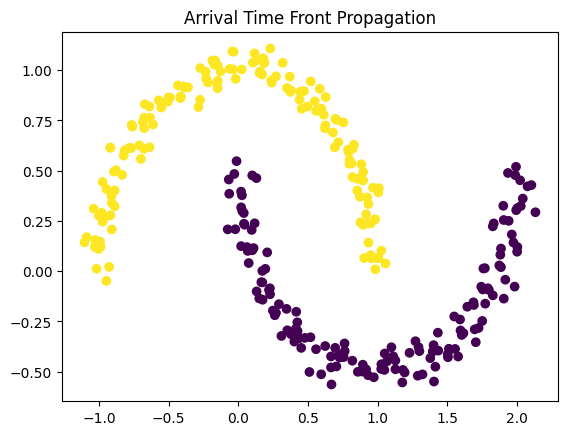

In [19]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

atfp = ArrivalTimeFrontPropagation(
    n_clusters=2,

)

labels = atfp.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Arrival Time Front Propagation")
plt.show()
